# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [225]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [226]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [227]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数

In [325]:
instrument_id = '511090'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,
    'open_confidence': 0.4,
    'close_confidence': 0.6,
    'standard_num': 1000,
    'trailing_stop_pct': 0.001,
    'max_pct': 0.004,
    'min_pct': 0.001,

    'k_pct': 1,
    'k_up': 3,
    'k_down': 3
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [326]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

train_dates, valid_dates, test_dates = split_dates(trade_dates,35,9,10)

总交易日数量: 54
交易日范围: 20260105 ~ 20260327
训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260313 (9天)
测试集: 20260316 ~ 20260327 (10天)


## 生成训练数据

In [327]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20260105: 产生 924 个样本
20260106: 产生 858 个样本
20260107: 产生 909 个样本
20260108: 产生 852 个样本
20260109: 产生 866 个样本
20260112: 产生 958 个样本
20260113: 产生 842 个样本
20260114: 产生 890 个样本
20260115: 产生 905 个样本
20260116: 产生 923 个样本
20260119: 产生 884 个样本
20260120: 产生 904 个样本
20260121: 产生 942 个样本
20260122: 产生 896 个样本
20260123: 产生 926 个样本
20260126: 产生 968 个样本
20260127: 产生 932 个样本
20260128: 产生 925 个样本
20260129: 产生 951 个样本
20260130: 产生 994 个样本
20260202: 产生 985 个样本
20260203: 产生 945 个样本
20260204: 产生 907 个样本
20260205: 产生 948 个样本
20260206: 产生 916 个样本
20260209: 产生 947 个样本
20260210: 产生 968 个样本
20260211: 产生 926 个样本
20260212: 产生 901 个样本
20260213: 产生 903 个样本
20260224: 产生 980 个样本
20260225: 产生 951 个样本
20260226: 产生 938 个样本
20260227: 产生 918 个样本
20260302: 产生 939 个样本
训练集样本: X=(32321, 13), y=(32321,)
标签分布:
0    23208
1     9113
Name: count, dtype: int64


In [328]:
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260303: 产生 956 个样本
20260304: 产生 905 个样本
20260305: 产生 894 个样本
20260306: 产生 931 个样本
20260309: 产生 917 个样本
20260310: 产生 968 个样本
20260311: 产生 916 个样本
20260312: 产生 954 个样本
20260313: 产生 907 个样本
验证集样本: X=(8348, 13), y=(8348,)
标签分布:
0    5961
1    2387
Name: count, dtype: int64


In [329]:
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")
if len(y_test) > 0:
    print(f"标签分布:\n{y_test.value_counts()}")

生成测试集样本...
20260316: 产生 928 个样本
20260317: 产生 922 个样本
20260318: 产生 957 个样本
20260319: 产生 1009 个样本
20260320: 产生 993 个样本
20260323: 产生 949 个样本
20260324: 产生 984 个样本
20260325: 产生 943 个样本
20260326: 产生 890 个样本
20260327: 产生 898 个样本
测试集样本: X=(9473, 13), y=(9473,)
标签分布:
0    6768
1    2705
Name: count, dtype: int64


## 训练模型

In [332]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict)

训练 xgboost 模型...
[0]	validation_0-logloss:0.60495
[1]	validation_0-logloss:0.60416
[2]	validation_0-logloss:0.60338
[3]	validation_0-logloss:0.60260
[4]	validation_0-logloss:0.60186
[5]	validation_0-logloss:0.60113
[6]	validation_0-logloss:0.60039
[7]	validation_0-logloss:0.59966
[8]	validation_0-logloss:0.59895
[9]	validation_0-logloss:0.59822
[10]	validation_0-logloss:0.59755
[11]	validation_0-logloss:0.59684
[12]	validation_0-logloss:0.59617
[13]	validation_0-logloss:0.59548
[14]	validation_0-logloss:0.59484
[15]	validation_0-logloss:0.59479
[16]	validation_0-logloss:0.59414
[17]	validation_0-logloss:0.59352
[18]	validation_0-logloss:0.59291
[19]	validation_0-logloss:0.59231
[20]	validation_0-logloss:0.59169
[21]	validation_0-logloss:0.59107
[22]	validation_0-logloss:0.59051
[23]	validation_0-logloss:0.58994
[24]	validation_0-logloss:0.58939
[25]	validation_0-logloss:0.58937
[26]	validation_0-logloss:0.58878
[27]	validation_0-logloss:0.58874
[28]	validation_0-logloss:0.58871
[29]	va

## 测试模型

测试集准确率: 0.7010

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80      6768
           1       0.47      0.34      0.39      2705

    accuracy                           0.70      9473
   macro avg       0.61      0.59      0.60      9473
weighted avg       0.68      0.70      0.69      9473


PR曲线AUC: 0.4256
平均精度 (AP): 0.4260

预测概率统计:
  均值: 0.3651
  标准差: 0.1491
  最小值: 0.0163
  25%分位数: 0.2521
  中位数: 0.3788
  75%分位数: 0.4821
  最大值: 0.8442

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3379, 标准差=0.1488
  标签1 (正类): 均值=0.4334, 标准差=0.1262


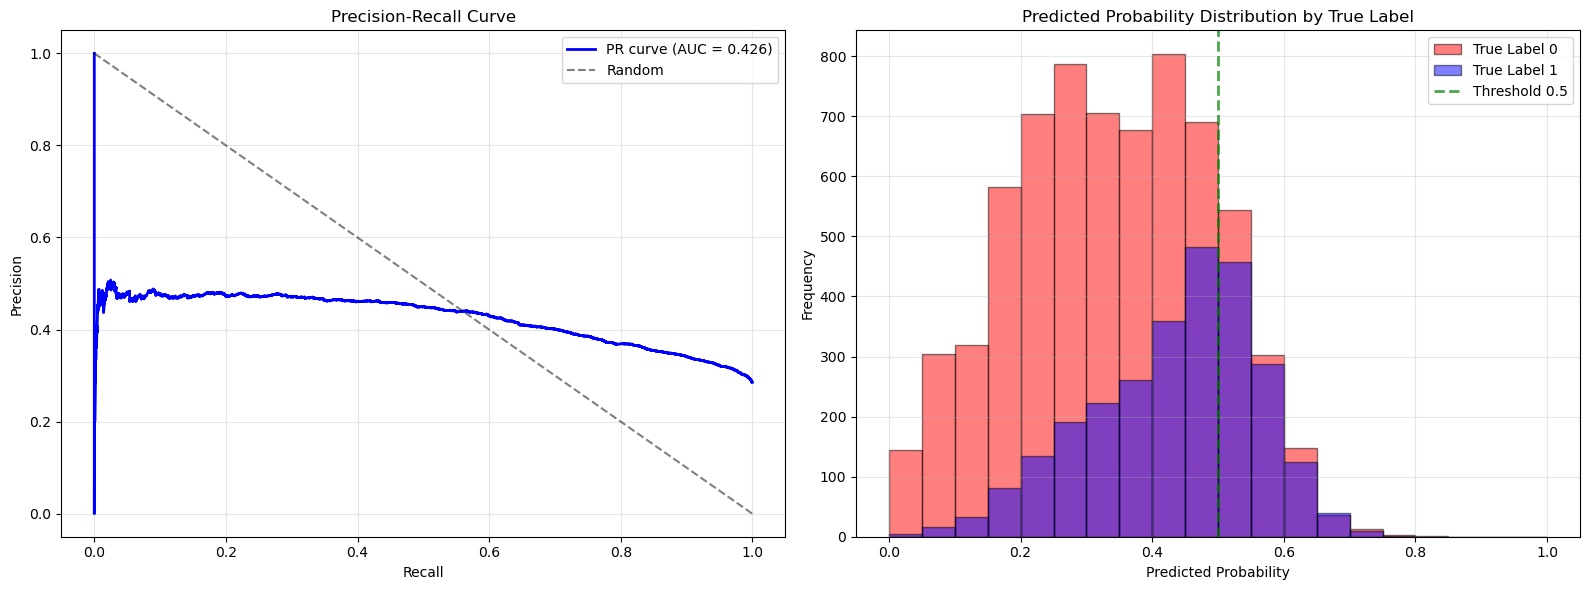

In [333]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

测试集准确率: 0.6700

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77      5659
           1       0.44      0.43      0.44      2378

    accuracy                           0.67      8037
   macro avg       0.60      0.60      0.60      8037
weighted avg       0.67      0.67      0.67      8037

## 创建策略实例

In [334]:
strategy = StrategyDemo(model, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1


## 使用backtesting工具进行回测

In [ ]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from multi_day_backtest import backtest_multi_days, backtest_summary
from delta.strategy import StrategyDemo

result_df = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd='20260303',
    end_ymd='20260330',
    StrategyClass= StrategyDemo,
    model = model,
    param_dict=param_dict,
    official = True
)

summary = backtest_summary(result_df)
print(summary)

/home/jovyan/work/backtest_result/511090_20260303_delta_v1.pkl 已请求
日期 20260303 完成，盈亏: -28.10, 成交: 8次
/home/jovyan/work/backtest_result/511090_20260304_delta_v1.pkl 已请求
日期 20260304 完成，盈亏: 2.80, 成交: 4次
/home/jovyan/work/backtest_result/511090_20260305_delta_v1.pkl 已请求
日期 20260305 完成，盈亏: -27.10, 成交: 6次
/home/jovyan/work/backtest_result/511090_20260306_delta_v1.pkl 已请求
日期 20260306 完成，盈亏: 0.60, 成交: 4次

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
2026011

In [299]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(result_df)

,trade_ymd,profits,trades,trade_date
0,20260303,16.0,40,2026-03-03
1,20260304,-4.5,58,2026-03-04
2,20260305,-0.4,38,2026-03-05
3,20260306,0.3,24,2026-03-06
4,20260309,9.2,40,2026-03-09
5,20260310,-5.8,22,2026-03-10
6,20260311,8.2,14,2026-03-11
7,20260312,2.1,20,2026-03-12
8,20260313,3.5,18,2026-03-13
9,20260316,3.0,26,2026-03-16


## 保存回测结果

In [300]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果
result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_20260410_081925
回测结果已保存到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_20260410_081925
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [241]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260408", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260408", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹

总共删除了 0 个文件夹


## 单日回测观察

In [281]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,
    'open_confidence': 0.4,
    'close_confidence': 0.6,
    'standard_num': 1000,
    'trailing_stop_pct': 0.001,
    'max_pct': 0.004,
    'min_pct': 0.001,

    'k_pct': 1,
    'k_up': 3,
    'k_down': 3
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])
strategy = StrategyDemo(model, param_dict)

/home/jovyan/work/backtest_result/518880_20260105_delta_v1.pkl 已请求


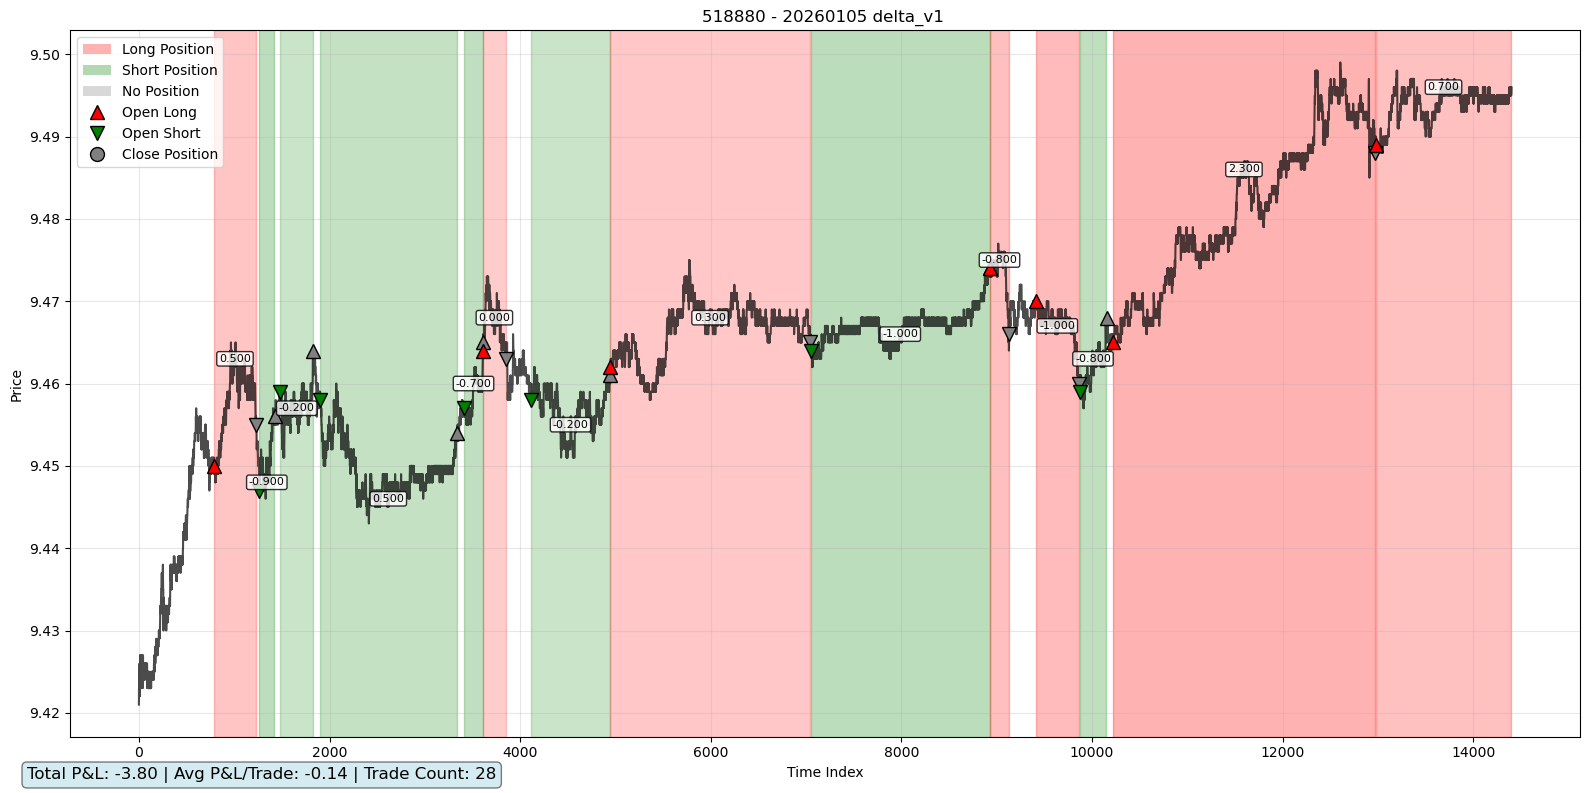

In [320]:
from single_day_backtest import single_day_backtest
hh = single_day_backtest(instrument_id,'20260105',StrategyDemo,model,param_dict,official=True)